<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">NOTEBOOK FEATURES COMPARABLES — FRANCE ENTIÈRE</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook construit les variables de comparabilité sur le périmètre DVF complet issu du notebook 00_06. Toulouse n'est plus utilisée comme base de calcul ; elle peut seulement servir de contrôle local.</p>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Positionnement</h3>
  <div style="color: #4b5563; font-size: 14px;">L'approche proposée est cohérente : un comparable doit être proche dans l'espace, proche dans le temps, proche par nature de bien et proche économiquement. La vigilance principale est l'anti-fuite temporelle : les agrégats de marché doivent être calculés uniquement avec des ventes antérieures à la transaction évaluée.</div>
</div>

In [2]:

# Imports et paramètres projet
 

from __future__ import annotations

from pathlib import Path
from typing import Iterable, Sequence
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TEMPORAL_00_06_TABLE_DIR = PROJECT_ROOT / "outputs" / "temporel_v4" / "tables"

OUTPUT_DIR = PROJECT_ROOT / "outputs_notebook_features_comparables_v3_france_entiere"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MI_SAMPLE_SIZE = 50_000

# Paramètres métier modifiables.
# VILLE_SELECTIONNEE reste disponible uniquement pour les contrôles locaux,
# mais la base de features est construite sur le périmètre France entière / DVF.
VILLE_SELECTIONNEE = "Toulouse"
RAYONS_METRES = [300, 500, 1_000, 2_000]
FENETRES_TEMPORELLES_MOIS = [12, 24, 36]
TOLERANCES_SURFACE = [0.10, 0.20]
MAX_VOISINS_GEO = 2_000

# Calcul national des features géographiques.
# Le groupement par département est un compromis robuste : il évite le biais Toulouse
# et permet des comparables inter-communes, tout en maîtrisant le temps de calcul.
RUN_FRANCE_ENTIERE = True
GEO_GROUP_PREFERENCE = ["code_departement", "departement", "code_commune"]
MAX_GROUPES_TEST = None  # Exemple : 10 pour tester avant lancement complet.


def save_fig(name: str) -> None:
    """Sauvegarde une figure Matplotlib dans le dossier de sortie."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()


print("Racine projet :", PROJECT_ROOT)
print("Sorties :", OUTPUT_DIR)


Racine projet : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Sorties : c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs_notebook_features_comparables_v3_france_entiere


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Chargement aligné sur le notebook 00_06</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette cellule reprend la hiérarchie de fichiers du notebook 00_06_donnees_temporelles. Elle charge la base transactionnelle utilisée par 00_06, puis tente d'ajouter les exports temporels mensuels produits par 00_06 dans outputs/temporel_v4/tables. Ce choix évite de repartir d'une autre base comparable ou d'une version non alignée du pipeline.</div>
</div>

In [3]:

# Chargement robuste aligné sur le notebook précédent


# Cette liste reprend volontairement l'ordre de priorité du notebook 00_06 joint.
# Elle permet de garantir que le notebook features comparables travaille sur la
# même base transactionnelle que l'étape temporelle du pipeline DVF.
candidate_files_00_06 = [
    DATA_PROCESSED / "base_modelisation_avec_features_marche_v8_strict_safe.parquet",
    DATA_PROCESSED / "base_modelisation_avec_features_marche_v8.parquet",
    DATA_PROCESSED / "base_modelisation_avec_features_marche_v6_strict_safe.parquet",
    DATA_PROCESSED / "base_modelisation_avec_features_marche_v6.parquet",
    DATA_PROCESSED / "dvf_enrichissement_territorial_v18.parquet",
    DATA_PROCESSED / "dvf_enrichissement_territorial_light_v18.parquet",
    DATA_PROCESSED / "dvf_enrichissement_territorial_v17.parquet",
    DATA_PROCESSED / "dvf_enrichissement_territorial_v14.parquet",
    DATA_PROCESSED / "base_micro_enrichie_territoriale.parquet",
    DATA_PROCESSED / "gdf_logements_iris.parquet",
    DATA_PROCESSED / "df_clean_dv.parquet",
    DATA_PROCESSED / "base_comparable_modelisation.parquet",
]

source_file = next((path for path in candidate_files_00_06 if path.exists()), None)

if source_file is None:
    checked = "\n".join(f"- {path}" for path in candidate_files_00_06)
    raise FileNotFoundError(
        "Aucun fichier transactionnel compatible avec le notebook 00_06 n'a été trouvé.\n"
        "Exécuter d'abord le notebook 00_06_donnees_temporelles ou vérifier data/processed.\n"
        f"Fichiers contrôlés :\n{checked}"
    )

df_raw = pd.read_parquet(source_file).copy()

# Harmonisation identique à 00_06 : certains notebooks amont exportent prix_m2_model.
if "prix_m2" not in df_raw.columns and "prix_m2_model" in df_raw.columns:
    df_raw["prix_m2"] = df_raw["prix_m2_model"]

# Exports temporels produits par le notebook 00_06.
# Ces fichiers sont mensuels : ils peuvent enrichir la base par annee_mois,
# mais ils ne remplacent pas la base transactionnelle nécessaire aux comparables.
temporal_features_file = TEMPORAL_00_06_TABLE_DIR / "temporal_features_model_v4.parquet"
temporal_market_file = TEMPORAL_00_06_TABLE_DIR / "temporal_market_full_v4.parquet"

temporal_features_00_06 = None
temporal_market_00_06 = None

if temporal_features_file.exists():
    temporal_features_00_06 = pd.read_parquet(temporal_features_file)
    print("Features temporelles 00_06 chargées :", temporal_features_file)
else:
    print("Info : temporal_features_model_v4.parquet absent. Les features temporelles 00_06 ne seront pas fusionnées.")

if temporal_market_file.exists():
    temporal_market_00_06 = pd.read_parquet(temporal_market_file)
    print("Marché temporel complet 00_06 chargé :", temporal_market_file)
else:
    print("Info : temporal_market_full_v4.parquet absent. Le marché temporel complet 00_06 ne sera pas utilisé.")

print("Fichier transactionnel chargé selon la hiérarchie 00_06 :", source_file.name)
print("Lignes :", f"{len(df_raw):,}")
print("Colonnes :", df_raw.shape[1])
display(df_raw.head(3))


FileNotFoundError: Aucun fichier transactionnel compatible avec le notebook 00_06 n'a Ã©tÃ© trouvÃ©.
ExÃ©cuter d'abord le notebook 00_06_donnees_temporelles ou vÃ©rifier data/processed.
Fichiers contrÃ´lÃ©s :
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\base_modelisation_avec_features_marche_v8_strict_safe.parquet
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\base_modelisation_avec_features_marche_v8.parquet
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\base_modelisation_avec_features_marche_v6_strict_safe.parquet
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\base_modelisation_avec_features_marche_v6.parquet
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\dvf_enrichissement_territorial_v18.parquet
- c:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\dv

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Harmonisation minimale</h3>
  <div style="color: #4b5563; font-size: 14px;">Les noms de colonnes peuvent varier selon les versions du pipeline. Cette cellule crée des alias stables pour les variables nécessaires aux comparables : prix, surface, date, coordonnées, type de bien et territoire.</div>
</div>

In [ ]:

# 2. Harmonisation des variables principales

def first_existing(columns: Sequence[str], candidates: Sequence[str]) -> str | None:
    """Retourne la première colonne disponible parmi une liste de candidats."""
    return next((col for col in candidates if col in columns), None)


COLS = {
    "prix_m2": first_existing(df_raw.columns, ["prix_m2", "prix_m2_model"]),
    "valeur": first_existing(df_raw.columns, ["valeur_fonciere", "valeur"]),
    "surface": first_existing(df_raw.columns, ["surface_reference", "surface_reelle_bati", "surface_reference_model"]),
    "pieces": first_existing(df_raw.columns, ["nombre_pieces_principales", "nb_pieces_total"]),
    "date": first_existing(df_raw.columns, ["date_mutation", "date"]),
    "type_bien": first_existing(df_raw.columns, ["type_bien", "type_local"]),
    "iris": first_existing(df_raw.columns, ["code_iris", "iris"]),
    "commune": first_existing(df_raw.columns, ["code_commune", "code_insee"]),
    "nom_commune": first_existing(df_raw.columns, ["nom_commune", "commune"]),
    "departement": first_existing(df_raw.columns, ["code_departement", "departement"]),
    "lat": first_existing(df_raw.columns, ["latitude", "lat"]),
    "lon": first_existing(df_raw.columns, ["longitude", "lon", "lng"]),
}

audit_cols = pd.DataFrame([
    {"role": role, "colonne": col, "presente": col is not None}
    for role, col in COLS.items()
])
display(audit_cols)

required_roles = ["prix_m2", "surface", "date", "lat", "lon"]
missing_required = [role for role in required_roles if COLS[role] is None]

if missing_required:
    raise ValueError(f"Colonnes obligatoires absentes : {missing_required}")

base = df_raw.copy()
base["prix_m2_cible"] = pd.to_numeric(base[COLS["prix_m2"]], errors="coerce")
base["surface_bien"] = pd.to_numeric(base[COLS["surface"]], errors="coerce")
base["date_mutation"] = pd.to_datetime(base[COLS["date"]], errors="coerce")
base["annee_mois"] = base["date_mutation"].dt.to_period("M").astype("string")
base["latitude"] = pd.to_numeric(base[COLS["lat"]], errors="coerce")
base["longitude"] = pd.to_numeric(base[COLS["lon"]], errors="coerce")

if COLS["pieces"] is not None:
    base["nb_pieces"] = pd.to_numeric(base[COLS["pieces"]], errors="coerce")
else:
    base["nb_pieces"] = np.nan

if COLS["type_bien"] is not None:
    base["type_bien"] = base[COLS["type_bien"]].astype("string")
else:
    base["type_bien"] = "Non renseigné"

if COLS["nom_commune"] is not None:
    base["nom_commune"] = base[COLS["nom_commune"]].astype("string")

if COLS["commune"] is not None:
    base["code_commune"] = base[COLS["commune"]].astype("string")

if COLS["iris"] is not None:
    base["code_iris"] = base[COLS["iris"]].astype("string")

# Fusion optionnelle des features temporelles mensuelles produites par 00_06.
# Les colonnes sont suffixées pour distinguer les variables natives de la base
# et les indicateurs temporels issus du notebook amont.
if temporal_features_00_06 is not None and "annee_mois" in temporal_features_00_06.columns:
    temporal_to_merge = temporal_features_00_06.copy()
    temporal_to_merge["annee_mois"] = temporal_to_merge["annee_mois"].astype("string")
    rename_temporal = {
        col: f"t06_{col}"
        for col in temporal_to_merge.columns
        if col != "annee_mois" and col in base.columns
    }
    temporal_to_merge = temporal_to_merge.rename(columns=rename_temporal)
    base = base.merge(temporal_to_merge, on="annee_mois", how="left", validate="many_to_one")
    print("Fusion features temporelles 00_06 :", temporal_to_merge.shape)
else:
    print("Fusion features temporelles 00_06 non réalisée.")

# Filtrage socle : uniquement les mutations exploitables pour une logique de comparable.
base = base[
    base["prix_m2_cible"].gt(0)
    & base["surface_bien"].gt(0)
    & base["date_mutation"].notna()
    & base["latitude"].between(41, 52)
    & base["longitude"].between(-6, 10)
].copy()

# Stabilisation de la cible : on conserve le prix brut et une cible logarithmique.
q_low, q_high = base["prix_m2_cible"].quantile([0.01, 0.99])
base["flag_prix_extreme"] = ~base["prix_m2_cible"].between(q_low, q_high)
base_model = base[~base["flag_prix_extreme"]].copy()
base_model["log_prix_m2"] = np.log1p(base_model["prix_m2_cible"])

print("Base exploitable :", f"{len(base_model):,}", "lignes")


,role,colonne,presente
0,prix_m2,prix_m2,True
1,valeur,valeur_fonciere,True
2,surface,surface_reference,True
3,pieces,nb_pieces_total,True
4,date,date_mutation,True
5,type_bien,type_bien,True
6,iris,code_iris,True
7,commune,code_commune,True
8,nom_commune,nom_commune,True
9,departement,code_departement,True


Fusion features temporelles 00_06 : (60, 14)
Base exploitable : 3,763,971 lignes


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features bien</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces variables décrivent le bien lui-même. Elles sont indispensables, mais il faut éviter d'y inclure des variables qui seraient directement équivalentes à la cible à prédire.</div>
</div>

In [ ]:

# 3. Features bien

def add_property_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute les variables relatives aux caractéristiques intrinsèques du bien."""
    out = df.copy()

    out["surface_log"] = np.log1p(out["surface_bien"])
    out["surface_sqrt"] = np.sqrt(out["surface_bien"])
    out["surface_classe"] = pd.cut(
        out["surface_bien"],
        bins=[0, 25, 40, 60, 80, 100, 150, np.inf],
        labels=["<=25", "25-40", "40-60", "60-80", "80-100", "100-150", ">150"],
        include_lowest=True,
    ).astype("string")

    out["pieces_par_m2"] = out["nb_pieces"] / out["surface_bien"].replace(0, np.nan)
    out["surface_par_piece"] = out["surface_bien"] / out["nb_pieces"].replace(0, np.nan)
    out["flag_piece_absente"] = out["nb_pieces"].isna().astype(int)

    return out


base_features = add_property_features(base_model)

display(base_features[["surface_bien", "surface_log", "nb_pieces", "surface_par_piece", "type_bien"]].head())


,surface_bien,surface_log,nb_pieces,surface_par_piece,type_bien
0,97.00,4.584967,5.0,19.400000,Maison
1,100.00,4.615121,4.0,25.000000,Maison
2,174.48,5.167525,4.0,43.620000,Appartement
3,70.00,4.262680,3.0,23.333333,Maison
4,70.00,4.262680,5.0,14.000000,Maison


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features temporelles</h3>
  <div style="color: #4b5563; font-size: 14px;">Les variables temporelles captent saisonnalité et ancienneté de marché. Elles ne créent pas de fuite car elles ne regardent pas les transactions futures.</div>
</div>

In [ ]:

# 4. Features temporelles

def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute des variables calendaires et saisonnières."""
    out = df.copy()
    dt = out["date_mutation"]

    out["annee_mutation"] = dt.dt.year
    out["mois_mutation"] = dt.dt.month
    out["trimestre_mutation"] = dt.dt.quarter
    out["jour_annee_mutation"] = dt.dt.dayofyear

    # Encodage cyclique : décembre et janvier restent proches.
    out["mois_sin"] = np.sin(2 * np.pi * out["mois_mutation"] / 12)
    out["mois_cos"] = np.cos(2 * np.pi * out["mois_mutation"] / 12)

    min_date = dt.min()
    out["anciennete_jours_depuis_debut"] = (dt - min_date).dt.days

    return out


base_features = add_temporal_features(base_features)

display(base_features[["date_mutation", "annee_mutation", "mois_mutation", "mois_sin", "mois_cos"]].head())


,date_mutation,annee_mutation,mois_mutation,mois_sin,mois_cos
0,2021-01-05,2021,1,5.000000e-01,8.660254e-01
1,2021-01-08,2021,1,5.000000e-01,8.660254e-01
2,2021-04-01,2021,4,8.660254e-01,-5.000000e-01
3,2021-03-03,2021,3,1.000000e+00,6.123234e-17
4,2021-12-10,2021,12,-2.449294e-16,1.000000e+00


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features économiques par groupes temporels</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces variables mesurent le niveau de marché historique sur un territoire ou un segment. Le calcul utilise shift(1) pour exclure la vente courante et préserver l'anti-fuite temporelle.</div>
</div>

In [ ]:

# 5. Agrégats économiques passés sans fuite temporelle


def add_past_group_stats(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    prefix: str,
    windows: Sequence[int] = (5, 10, 20),
) -> pd.DataFrame:
    """Ajoute des statistiques historiques par groupe, calculées avant la vente courante.

    Les fenêtres sont exprimées en nombre de mutations précédentes dans le groupe.
    Cette méthode reste plus robuste et portable qu'une fenêtre calendaire quand les volumes
    varient fortement d'une commune à l'autre.
    """
    out = df.sort_values(list(group_cols) + ["date_mutation"]).copy()
    grp = out.groupby(list(group_cols), dropna=False)["prix_m2_cible"]

    # Statistiques cumulées historiques : uniquement les ventes précédentes.
    out[f"{prefix}_prix_m2_moy_passe"] = grp.expanding().mean().shift(1).reset_index(level=list(range(len(group_cols))), drop=True)
    out[f"{prefix}_prix_m2_med_passe"] = grp.expanding().median().shift(1).reset_index(level=list(range(len(group_cols))), drop=True)
    out[f"{prefix}_nb_ventes_passe"] = grp.cumcount()

    for window in windows:
        rolled = grp.rolling(window=window, min_periods=3)
        out[f"{prefix}_prix_m2_moy_{window}v"] = rolled.mean().shift(1).reset_index(level=list(range(len(group_cols))), drop=True)
        out[f"{prefix}_prix_m2_std_{window}v"] = rolled.std().shift(1).reset_index(level=list(range(len(group_cols))), drop=True)

    return out.sort_index()


# Les groupes sont ajoutés uniquement si les colonnes existent.
if "code_commune" in base_features.columns:
    base_features = add_past_group_stats(base_features, ["code_commune"], "commune")

if {"code_commune", "type_bien"}.issubset(base_features.columns):
    base_features = add_past_group_stats(base_features, ["code_commune", "type_bien"], "commune_type")

if "code_iris" in base_features.columns:
    base_features = add_past_group_stats(base_features, ["code_iris"], "iris")

past_cols = [col for col in base_features.columns if "_passe" in col or col.endswith("v")]
display(base_features[past_cols].head())


,commune_prix_m2_moy_passe,commune_prix_m2_med_passe,commune_nb_ventes_passe,commune_prix_m2_moy_5v,commune_prix_m2_std_5v,commune_prix_m2_moy_10v,commune_prix_m2_std_10v,commune_prix_m2_moy_20v,commune_prix_m2_std_20v,commune_type_prix_m2_moy_passe,commune_type_prix_m2_med_passe,commune_type_nb_ventes_passe,commune_type_prix_m2_moy_5v,commune_type_prix_m2_std_5v,commune_type_prix_m2_moy_10v,commune_type_prix_m2_std_10v,commune_type_prix_m2_moy_20v,commune_type_prix_m2_std_20v,iris_prix_m2_moy_passe,iris_prix_m2_med_passe,iris_nb_ventes_passe,iris_prix_m2_moy_5v,iris_prix_m2_std_5v,iris_prix_m2_moy_10v,iris_prix_m2_std_10v,iris_prix_m2_moy_20v,iris_prix_m2_std_20v
0,1679.406976,1479.665072,0,1638.821653,512.594063,1679.406976,801.607776,1679.406976,801.607776,1682.242991,1682.242991,0,NaN,NaN,NaN,NaN,NaN,NaN,1679.406976,1479.665072,0,1638.821653,512.594063,1679.406976,801.607776,1679.406976,801.607776
1,1337.573660,1337.573660,1,NaN,NaN,NaN,NaN,NaN,NaN,1521.673250,1290.689257,0,1097.926076,413.994520,1222.706522,782.361516,1455.663703,759.330239,1337.573660,1337.573660,1,NaN,NaN,NaN,NaN,NaN,NaN
2,1616.700173,1626.661377,145,1498.942406,698.336299,1104.040658,669.783199,1135.368859,678.060817,1460.417314,1523.762455,116,1498.942406,698.336299,1024.400325,685.261337,1134.246896,765.953404,1472.914695,1443.464314,4,1472.914695,434.551304,1472.914695,434.551304,1472.914695,434.551304
3,1130.050505,1130.050505,2,NaN,NaN,NaN,NaN,NaN,NaN,1130.050505,1130.050505,2,NaN,NaN,NaN,NaN,NaN,NaN,1130.050505,1130.050505,2,NaN,NaN,NaN,NaN,NaN,NaN
4,1319.056704,1250.000000,419,1104.347726,227.602639,1106.678320,413.761573,1302.729272,503.637465,1326.183744,1234.782609,309,1104.347726,227.602639,1089.238364,170.765149,1372.579042,593.068600,1262.453396,1234.545765,42,1198.827841,381.744386,1129.830194,386.571859,1245.403422,571.293409


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features géographiques locales</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette partie explore les ventes dans des périmètres de 200 m, 300 m, 500 m et 1 km. Pour rester exploitable, le calcul utilise BallTree si disponible, limite le nombre de voisins et filtre ensuite par temporalité, type de bien et surface.</div>
</div>

In [ ]:

# 6. Features de voisinage géographique et comparabilité métier


EARTH_RADIUS_M = 6_371_000


def haversine_meters(lat1, lon1, lat2, lon2):
    """Calcule une distance haversine en mètres entre deux points ou séries de points."""
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))


def add_geo_neighbor_features(
    df: pd.DataFrame,
    radii_m: Sequence[int] = RAYONS_METRES,
    windows_months: Sequence[int] = FENETRES_TEMPORELLES_MOIS,
    max_neighbors: int = MAX_VOISINS_GEO,
) -> pd.DataFrame:
    """Ajoute des indicateurs de marché local autour de chaque mutation.

    Règles appliquées :
    - rayon géographique en mètres ;
    - vente strictement antérieure à la mutation courante ;
    - mêmes fenêtres temporelles passées ;
    - variantes tous biens et même type de bien ;
    - indicateurs de médiane, dispersion et profondeur.
    """
    try:
        from sklearn.neighbors import BallTree
    except ImportError as exc:
        raise ImportError("scikit-learn est requis pour BallTree.") from exc

    out = df.reset_index(drop=False).rename(columns={"index": "_original_index"}).copy()
    coords_rad = np.radians(out[["latitude", "longitude"]].to_numpy())
    tree = BallTree(coords_rad, metric="haversine")

    # Initialisation des colonnes pour éviter les insertions répétées dans la boucle.
    feature_data: dict[str, np.ndarray] = {}
    for radius in radii_m:
        for months in windows_months:
            for suffix in ["all", "same_type", "surface_20"]:
                stem = f"geo_{radius}m_{months}m_{suffix}"
                feature_data[f"{stem}_nb"] = np.zeros(len(out), dtype=float)
                feature_data[f"{stem}_prix_m2_med"] = np.full(len(out), np.nan, dtype=float)
                feature_data[f"{stem}_prix_m2_iqr"] = np.full(len(out), np.nan, dtype=float)
                feature_data[f"{stem}_dist_med"] = np.full(len(out), np.nan, dtype=float)

    max_radius_rad = max(radii_m) / EARTH_RADIUS_M
    neighbor_indices, neighbor_distances = tree.query_radius(
        coords_rad,
        r=max_radius_rad,
        return_distance=True,
        sort_results=True,
    )

    dates = out["date_mutation"].to_numpy(dtype="datetime64[ns]")
    prices = out["prix_m2_cible"].to_numpy(dtype=float)
    types = out["type_bien"].astype("string").to_numpy()
    surfaces = out["surface_bien"].to_numpy(dtype=float)

    for i in range(len(out)):
        idx = neighbor_indices[i]
        dist_m = neighbor_distances[i] * EARTH_RADIUS_M

        # On exclut la mutation elle-même et on limite les voisins pour maîtriser le temps de calcul.
        valid = idx != i
        idx = idx[valid][:max_neighbors]
        dist_m = dist_m[valid][:max_neighbors]

        if len(idx) == 0:
            continue

        past_mask = dates[idx] < dates[i]
        if not past_mask.any():
            continue

        idx = idx[past_mask]
        dist_m = dist_m[past_mask]

        for radius in radii_m:
            radius_mask = dist_m <= radius
            if not radius_mask.any():
                continue

            idx_radius = idx[radius_mask]
            dist_radius = dist_m[radius_mask]

            for months in windows_months:
                min_date = dates[i] - np.timedelta64(int(months * 31), "D")
                time_mask = dates[idx_radius] >= min_date
                if not time_mask.any():
                    continue

                idx_time = idx_radius[time_mask]
                dist_time = dist_radius[time_mask]

                masks = {
                    "all": np.ones(len(idx_time), dtype=bool),
                    "same_type": types[idx_time] == types[i],
                    "surface_20": np.abs(surfaces[idx_time] / surfaces[i] - 1) <= 0.20,
                }

                for suffix, mask in masks.items():
                    if not mask.any():
                        continue

                    selected_prices = prices[idx_time[mask]]
                    selected_dist = dist_time[mask]
                    selected_prices = selected_prices[np.isfinite(selected_prices)]

                    if len(selected_prices) == 0:
                        continue

                    stem = f"geo_{radius}m_{months}m_{suffix}"
                    q1, q3 = np.nanquantile(selected_prices, [0.25, 0.75])

                    feature_data[f"{stem}_nb"][i] = len(selected_prices)
                    feature_data[f"{stem}_prix_m2_med"][i] = np.nanmedian(selected_prices)
                    feature_data[f"{stem}_prix_m2_iqr"][i] = q3 - q1
                    feature_data[f"{stem}_dist_med"][i] = np.nanmedian(selected_dist)

    features = pd.DataFrame(feature_data)
    out = pd.concat([out, features], axis=1)
    out = out.set_index("_original_index").sort_index()
    out.index.name = None
    return out

print("Fonction add_geo_neighbor_features prête : calcul national réalisé dans la cellule suivante.")


Fonction add_geo_neighbor_features prête : calcul national réalisé dans la cellule suivante.


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CALCUL FRANCE ENTIÈRE</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette section calcule les comparables géographiques sur l'ensemble du périmètre DVF exploitable. Le calcul n'est plus limité à Toulouse.</div>
</div>

In [ ]:

# 7. Calcul France entière des features locales


# Important : on ne filtre plus sur Toulouse.
# Les features géographiques sont calculées sur tout le périmètre DVF exploitable.
# Le groupement par département permet de capter les comparables de communes voisines,
# ce qu'un groupement strict par commune empêcherait.

def choose_geo_group_col(df: pd.DataFrame, preferences: Sequence[str]) -> str | None:
    """Choisit la meilleure colonne de groupement disponible pour le calcul géographique."""
    return next((col for col in preferences if col in df.columns), None)


if RUN_FRANCE_ENTIERE:
    group_col = choose_geo_group_col(base_features, GEO_GROUP_PREFERENCE)

    if group_col is None:
        raise ValueError(
            "Impossible de lancer le calcul national : aucune colonne de groupement "
            f"disponible parmi {GEO_GROUP_PREFERENCE}."
        )

    enriched_parts = []
    groupes = (
        base_features[group_col]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if MAX_GROUPES_TEST is not None:
        groupes = groupes[:MAX_GROUPES_TEST]
        print(f"Mode test : calcul limité aux {len(groupes)} premiers groupes.")

    print("Calcul des features géographiques France entière")
    print("Colonne de groupement :", group_col)
    print("Nombre de groupes :", len(groupes))

    for n, groupe in enumerate(groupes, start=1):
        part = base_features[base_features[group_col].eq(groupe)].copy()

        # Les petits groupes sont conservés, mais sans calcul BallTree coûteux.
        if len(part) < 10:
            enriched_parts.append(part)
            continue

        print(f"{n}/{len(groupes)} - {group_col}={groupe} - {len(part):,} lignes")
        enriched_parts.append(add_geo_neighbor_features(part))

    # On réintègre aussi les lignes sans groupe, pour ne pas perdre d'observations.
    missing_group_part = base_features[base_features[group_col].isna()].copy()
    if not missing_group_part.empty:
        enriched_parts.append(missing_group_part)

    base_features = pd.concat(enriched_parts, axis=0).sort_index()
    print("Calcul national terminé :", f"{len(base_features):,}", "lignes")
else:
    print("RUN_FRANCE_ENTIERE=False : calcul géographique national non lancé.")

# Diagnostic de couverture des features géographiques.
geo_cols = [col for col in base_features.columns if col.startswith("geo_")]

if geo_cols:
    coverage_geo = (
        base_features[geo_cols]
        .notna()
        .mean()
        .sort_values(ascending=False)
        .rename("taux_renseignement")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    print(
        "Lignes avec au moins une feature géographique renseignée :",
        int(base_features[geo_cols].notna().any(axis=1).sum()),
        "/",
        len(base_features),
    )

    display(coverage_geo.head(30))
    coverage_geo.to_csv(TABLE_DIR / "audit_couverture_features_geo.csv", index=False)
else:
    print("Aucune colonne géographique geo_* n'a été créée.")


Calcul des features géographiques France entière
Colonne de groupement : code_departement
Nombre de groupes : 95
1/95 - code_departement=01 - 36,861 lignes
2/95 - code_departement=02 - 25,314 lignes
3/95 - code_departement=03 - 18,045 lignes
4/95 - code_departement=04 - 14,343 lignes
5/95 - code_departement=05 - 15,659 lignes
6/95 - code_departement=06 - 116,104 lignes
7/95 - code_departement=07 - 18,069 lignes
8/95 - code_departement=08 - 12,633 lignes
9/95 - code_departement=09 - 11,229 lignes
10/95 - code_departement=10 - 17,451 lignes
11/95 - code_departement=11 - 36,248 lignes
12/95 - code_departement=12 - 15,719 lignes
13/95 - code_departement=13 - 128,608 lignes
14/95 - code_departement=14 - 49,151 lignes
15/95 - code_departement=15 - 7,642 lignes
16/95 - code_departement=16 - 19,892 lignes
17/95 - code_departement=17 - 56,234 lignes
18/95 - code_departement=18 - 16,736 lignes
19/95 - code_departement=19 - 12,800 lignes
20/95 - code_departement=21 - 36,743 lignes
21/95 - code_de

,feature,taux_renseignement
0,geo_300m_12m_all_nb,0.999043
1,geo_300m_36m_surface_20_nb,0.999043
2,geo_500m_12m_same_type_nb,0.999043
3,geo_500m_12m_surface_20_nb,0.999043
4,geo_500m_24m_all_nb,0.999043
5,geo_500m_24m_same_type_nb,0.999043
6,geo_500m_24m_surface_20_nb,0.999043
7,geo_500m_36m_all_nb,0.999043
8,geo_500m_36m_same_type_nb,0.999043
9,geo_500m_36m_surface_20_nb,0.999043


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Features de score comparable</h3>
  <div style="color: #4b5563; font-size: 14px;">Ces variables traduisent la logique métier en critères chiffrés : profondeur du marché local, écart au prix historique, dispersion locale, proximité surface/type et disponibilité des comparables.</div>
</div>

In [ ]:

# 8. Ratios économiques de comparabilité


def add_comparable_score_features(df: pd.DataFrame) -> pd.DataFrame:
    """Construit des ratios qui facilitent le scoring et la modélisation."""
    out = df.copy()

    median_cols = [col for col in out.columns if col.endswith("_prix_m2_med")]
    nb_cols = [col for col in out.columns if col.endswith("_nb") and col.startswith("geo_")]
    iqr_cols = [col for col in out.columns if col.endswith("_prix_m2_iqr")]

    for col in median_cols:
        out[f"ratio_prix_vs_{col}"] = out["prix_m2_cible"] / out[col].replace(0, np.nan)
        out[f"ecart_abs_prix_vs_{col}"] = (out["prix_m2_cible"] - out[col]).abs()

    if nb_cols:
        out["geo_nb_comparables_max"] = out[nb_cols].max(axis=1)
        out["geo_nb_comparables_500m_12m"] = out.get("geo_500m_12m_all_nb", np.nan)

    if iqr_cols:
        out["geo_iqr_prix_m2_min"] = out[iqr_cols].min(axis=1)
        out["geo_iqr_prix_m2_mediane"] = out[iqr_cols].median(axis=1)

    # Marché historique communal : écart à la médiane passée, quand disponible.
    for col in ["commune_prix_m2_med_passe", "commune_type_prix_m2_med_passe", "iris_prix_m2_med_passe"]:
        if col in out.columns:
            out[f"ratio_prix_vs_{col}"] = out["prix_m2_cible"] / out[col].replace(0, np.nan)
            out[f"ecart_pct_vs_{col}"] = out[f"ratio_prix_vs_{col}"] - 1

    return out


base_features = add_comparable_score_features(base_features)

feature_preview = [
    col for col in base_features.columns
    if col.startswith("geo_") or col.startswith("ratio_prix") or col.startswith("ecart_pct")
]
display(base_features[feature_preview[:20]].head())


,geo_300m_12m_all_nb,geo_300m_12m_all_prix_m2_med,geo_300m_12m_all_prix_m2_iqr,geo_300m_12m_all_dist_med,geo_300m_12m_same_type_nb,geo_300m_12m_same_type_prix_m2_med,geo_300m_12m_same_type_prix_m2_iqr,geo_300m_12m_same_type_dist_med,geo_300m_12m_surface_20_nb,geo_300m_12m_surface_20_prix_m2_med,geo_300m_12m_surface_20_prix_m2_iqr,geo_300m_12m_surface_20_dist_med,geo_300m_24m_all_nb,geo_300m_24m_all_prix_m2_med,geo_300m_24m_all_prix_m2_iqr,geo_300m_24m_all_dist_med,geo_300m_24m_same_type_nb,geo_300m_24m_same_type_prix_m2_med,geo_300m_24m_same_type_prix_m2_iqr,geo_300m_24m_same_type_dist_med
0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,3.0,1052.098571,299.980936,165.848831,3.0,1052.098571,299.980936,165.848831,1.0,562.828827,0.000000,165.848831,3.0,1052.098571,299.980936,165.848831,3.0,1052.098571,299.980936,165.848831
3,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,21.0,1112.903226,517.890081,187.614093,14.0,1124.633431,435.192502,161.064838,2.0,1696.825853,439.250096,225.770855,21.0,1112.903226,517.890081,187.614093,14.0,1124.633431,435.192502,161.064838


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Audit des features</h3>
  <div style="color: #4b5563; font-size: 14px;">On sépare l'audit métier de la sélection statistique. Une feature peut être conservée pour explicabilité même si son score statistique est modéré.</div>
</div>

In [ ]:

# 9. Catalogue et audit features


TARGET = "log_prix_m2"
EXCLUDE_FROM_FEATURES = {
    "prix_m2_cible", TARGET, "date_mutation", "valeur_fonciere", "id_mutation",
}

feature_candidates = [
    col for col in base_features.columns
    if col not in EXCLUDE_FROM_FEATURES
    and not col.startswith("prix_m2_model")
]

feature_catalog = pd.DataFrame({"variable": feature_candidates})
feature_catalog["dtype"] = feature_catalog["variable"].map(lambda c: str(base_features[c].dtype))
feature_catalog["pct_manquant"] = feature_catalog["variable"].map(lambda c: base_features[c].isna().mean())
feature_catalog["n_unique"] = feature_catalog["variable"].map(lambda c: base_features[c].nunique(dropna=True))

feature_catalog["famille"] = np.select(
    [
        feature_catalog["variable"].str.startswith("geo_"),
        feature_catalog["variable"].str.contains("commune|iris", case=False, regex=True),
        feature_catalog["variable"].str.contains("surface|piece|type_bien", case=False, regex=True),
        feature_catalog["variable"].str.contains("annee|mois|trimestre|jour|anciennete", case=False, regex=True),
        feature_catalog["variable"].str.contains("ratio|ecart|iqr|passe", case=False, regex=True),
    ],
    ["géographique", "territoriale", "bien", "temporelle", "économique"],
    default="autre",
)

feature_catalog = feature_catalog.sort_values(["famille", "pct_manquant", "variable"])
display(feature_catalog.head(50))


,variable,dtype,pct_manquant,n_unique,famille
33,avec_dependances,bool,0.0,2,autre
34,categorie_logement,object,0.0,2,autre
87,code_departement_tx,string,0.0,93,autre
72,dependance_info_disponible,int32,0.0,1,autre
54,flag_outlier,bool,0.0,1,autre
53,flag_outlier_prix_m2,bool,0.0,1,autre
51,flag_outlier_valeur_fonciere,bool,0.0,1,autre
159,flag_prix_extreme,bool,0.0,1,autre
50,flag_prix_m2_non_positif,bool,0.0,1,autre
45,flag_prix_m2_valide,bool,0.0,1,autre


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Sélection statistique</h3>
  <div style="color: #4b5563; font-size: 14px;">La sélection combine variance, complétude, Pearson, Spearman et information mutuelle. L'information mutuelle est échantillonnée pour éviter les traitements interminables.</div>
</div>

In [ ]:

# 10. Sélection de features data science


selection_base = base_features.copy()

# Encodage simple des catégorielles pour les méthodes numériques de sélection.
categorical_cols = [
    col for col in feature_candidates
    if col in selection_base.columns
    and selection_base[col].dtype.name in {"object", "string", "category"}
]

numeric_cols = [
    col for col in feature_candidates
    if col in selection_base.columns
    and pd.api.types.is_numeric_dtype(selection_base[col])
]

encoded = selection_base[numeric_cols].copy()


def safe_to_string(value):
    """Convertit les valeurs catégorielles, y compris les bytes mal encodés."""
    if pd.isna(value):
        return "__NA__"
    if isinstance(value, bytes):
        return value.decode("latin1", errors="replace")
    return str(value)


if categorical_cols:
    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    cat_values = selection_base[categorical_cols].map(safe_to_string)

    encoded_cats = pd.DataFrame(
        encoder.fit_transform(cat_values),
        columns=[f"{col}__encoded" for col in categorical_cols],
        index=selection_base.index,
    )

    encoded = pd.concat([encoded, encoded_cats], axis=1)

# Nettoyage des colonnes inutilisables.
encoded = encoded.replace([np.inf, -np.inf], np.nan)

valid_cols = [
    col for col in encoded.columns
    if encoded[col].nunique(dropna=True) > 1
]
encoded = encoded[valid_cols]

# Imputation médiane pour la sélection.
encoded = encoded.fillna(encoded.median(numeric_only=True))

y = selection_base[TARGET]
valid_mask = y.notna()
encoded = encoded.loc[valid_mask]
y = y.loc[valid_mask]

# Pearson et Spearman.
pearson = encoded.corrwith(y, method="pearson").rename("pearson")
spearman = encoded.corrwith(y, method="spearman").rename("spearman")

# Information mutuelle sur échantillon pour maîtriser le temps d'exécution.
if len(encoded) > MI_SAMPLE_SIZE:
    sample_idx = encoded.sample(
        MI_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    ).index
else:
    sample_idx = encoded.index

mi_values = mutual_info_regression(
    encoded.loc[sample_idx],
    y.loc[sample_idx],
    random_state=RANDOM_STATE,
)

mi = pd.Series(
    mi_values,
    index=encoded.columns,
    name="mutual_info",
)

feature_selection = (
    pd.concat([pearson, spearman, mi], axis=1)
    .reset_index()
    .rename(columns={"index": "variable_selection"})
)

# Rattachement au nom de variable d'origine pour les catégorielles encodées.
feature_selection["variable"] = (
    feature_selection["variable_selection"]
    .str.replace("__encoded", "", regex=False)
)

feature_selection["abs_pearson"] = feature_selection["pearson"].abs()
feature_selection["abs_spearman"] = feature_selection["spearman"].abs()

feature_selection["score_selection"] = (
    feature_selection["abs_pearson"].rank(pct=True)
    + feature_selection["abs_spearman"].rank(pct=True)
    + feature_selection["mutual_info"].rank(pct=True)
) / 3

feature_selection = feature_selection.merge(
    feature_catalog[["variable", "famille", "pct_manquant", "n_unique"]],
    on="variable",
    how="left",
)

feature_selection["decision"] = np.select(
    [
        feature_selection["pct_manquant"].gt(0.80),
        feature_selection["n_unique"].le(1),
        feature_selection["score_selection"].ge(0.70),
        feature_selection["famille"].isin(
            ["géographique", "économique", "temporelle"]
        ),
    ],
    [
        "écarter_manquant",
        "écarter_constante",
        "conserver_stat",
        "conserver_métier",
    ],
    default="à_revoir",
)

feature_selection = feature_selection.sort_values(
    "score_selection",
    ascending=False,
)

feature_selection.to_csv(TABLE_DIR / "selection_features_data_science.csv", index=False)
display(feature_selection.head(60))


,variable_selection,pearson,spearman,mutual_info,variable,abs_pearson,abs_spearman,score_selection,famille,pct_manquant,n_unique,decision
30,prix_m2_winsor_01_99,0.916828,1.000000,8.867576,prix_m2_winsor_01_99,0.916828,1.000000,0.998308,autre,0.000000e+00,1368403,conserver_stat
28,prix_m2_recalcule,0.916826,1.000000,8.867412,prix_m2_recalcule,0.916826,1.000000,0.997462,autre,0.000000e+00,1368802,conserver_stat
25,prix_m2,0.916826,1.000000,8.867281,prix_m2,0.916826,1.000000,0.996616,autre,0.000000e+00,1368802,conserver_stat
276,geo_2000m_36m_surface_20_prix_m2_med,0.706891,0.750008,0.487590,geo_2000m_36m_surface_20_prix_m2_med,0.706891,0.750008,0.987310,géographique,4.639302e-02,1596487,conserver_stat
264,geo_2000m_24m_surface_20_prix_m2_med,0.705006,0.745928,0.481116,geo_2000m_24m_surface_20_prix_m2_med,0.705006,0.745928,0.983080,géographique,5.128121e-02,1649319,conserver_stat
240,geo_1000m_36m_surface_20_prix_m2_med,0.701847,0.740506,0.492919,geo_1000m_36m_surface_20_prix_m2_med,0.701847,0.740506,0.982234,géographique,8.264702e-02,1612769,conserver_stat
272,geo_2000m_36m_same_type_prix_m2_med,0.703454,0.741436,0.451529,geo_2000m_36m_same_type_prix_m2_med,0.703454,0.741436,0.972927,géographique,1.404421e-02,1178100,conserver_stat
228,geo_1000m_24m_surface_20_prix_m2_med,0.698644,0.734698,0.484953,geo_1000m_24m_surface_20_prix_m2_med,0.698644,0.734698,0.969543,géographique,9.062530e-02,1655752,conserver_stat
204,geo_500m_36m_surface_20_prix_m2_med,0.694639,0.729379,0.494021,geo_500m_36m_surface_20_prix_m2_med,0.694639,0.729379,0.963621,géographique,1.296035e-01,1616619,conserver_stat
236,geo_1000m_36m_same_type_prix_m2_med,0.701242,0.736534,0.447203,geo_1000m_36m_same_type_prix_m2_med,0.701242,0.736534,0.962775,géographique,3.254781e-02,1271425,conserver_stat


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Redondance</h3>
  <div style="color: #4b5563; font-size: 14px;">Les features très corrélées entre elles sont signalées. La règle proposée est de conserver la variable la plus lisible métier ou celle dont le score de sélection est le plus élevé.</div>
</div>

In [ ]:

# 11. Analyse redondance


selected_for_corr = feature_selection.loc[
    feature_selection["decision"].isin(["conserver_stat", "conserver_métier"]),
    "variable_selection",
].tolist()
selected_for_corr = [col for col in selected_for_corr if col in encoded.columns]

if len(selected_for_corr) >= 2:
    corr_matrix = encoded[selected_for_corr].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    redundant_pairs = []
    for col in upper.columns:
        high_corr = upper.index[upper[col] >= 0.90].tolist()
        for row in high_corr:
            redundant_pairs.append({
                "feature_1": row,
                "feature_2": col,
                "correlation_abs": upper.loc[row, col],
            })

    redundant_features = pd.DataFrame(redundant_pairs).sort_values("correlation_abs", ascending=False)
else:
    redundant_features = pd.DataFrame(columns=["feature_1", "feature_2", "correlation_abs"])

display(redundant_features.head(50))


,feature_1,feature_2,correlation_abs
459,ecart_pct_vs_commune_type_prix_m2_med_passe,ratio_prix_vs_commune_type_prix_m2_med_passe,1.000000
836,annee_mois_mutation__encoded,annee_mois__encoded,1.000000
715,geo_nb_comparables_500m_12m,geo_500m_12m_all_nb,1.000000
2,prix_m2_recalcule,prix_m2,1.000000
851,trimestre_mutation,trimestre,1.000000
850,annee_mutation,annee,1.000000
838,annee_mois__encoded,mois_depuis_debut,1.000000
837,annee_mois_mutation__encoded,mois_depuis_debut,1.000000
828,ratio_bati_terrain_mutation,ratio_bati_terrain,1.000000
740,geo_2000m_36m_all_nb,geo_nb_comparables_max,1.000000


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Base features finale</h3>
  <div style="color: #4b5563; font-size: 14px;">La sortie principale est une base enrichie, destinée au notebook de modélisation. Elle conserve la cible, les identifiants utiles et les features validées ou à revoir.</div>
</div>

In [ ]:

# 12. Exports ultra-économes en mémoire

features_to_keep = (
    feature_selection.loc[
        feature_selection["decision"].isin(
            ["conserver_stat", "conserver_métier", "à_revoir"]
        ),
        "variable",
    ]
    .dropna()
    .drop_duplicates()
    .tolist()
)

id_cols = [
    col for col in [
        "date_mutation",
        "prix_m2_cible",
        "log_prix_m2",
        "surface_bien",
        "latitude",
        "longitude",
        "type_bien",
        "code_commune",
        "nom_commune",
        "code_iris",
    ]
    if col in base_features.columns
]

# Colonnes export uniques, sans recopier base_features
export_cols = list(dict.fromkeys(id_cols + features_to_keep))
export_cols = [col for col in export_cols if col in base_features.columns]

# On retire les colonnes dont le nom est dupliqué dans base_features
base_cols = pd.Series(base_features.columns)
unique_base_cols = base_cols[~base_cols.duplicated()].tolist()
export_cols = [col for col in export_cols if col in unique_base_cols]

base_features_file = TABLE_DIR / "base_features_comparables_v1.parquet"
feature_catalog_file = TABLE_DIR / "catalogue_features_comparables_v1.csv"
feature_selection_file = TABLE_DIR / "selection_features_comparables_v1.csv"
redundancy_file = TABLE_DIR / "redondance_features_comparables_v1.csv"

import pyarrow as pa
import pyarrow.parquet as pq
import gc

chunk_size = 100_000
writer = None

try:
    for start in range(0, len(base_features), chunk_size):
        end = min(start + chunk_size, len(base_features))

        # Sélection par chunk uniquement
        chunk = base_features.iloc[start:end].loc[:, export_cols]

        # Sécurité locale sur le chunk
        chunk = chunk.loc[:, ~chunk.columns.duplicated()]

        table = pa.Table.from_pandas(
            chunk,
            preserve_index=False,
            safe=False,
        )

        if writer is None:
            writer = pq.ParquetWriter(
                base_features_file,
                table.schema,
                compression="snappy",
            )

        writer.write_table(table)

        del chunk, table
        gc.collect()

        print(f"Export parquet : lignes {start:,} à {end:,}")

finally:
    if writer is not None:
        writer.close()

feature_catalog.to_csv(feature_catalog_file, index=False)
feature_selection.to_csv(feature_selection_file, index=False)
redundant_features.to_csv(redundancy_file, index=False)

print("Base features exportée :", base_features_file)
print("Catalogue features :", feature_catalog_file)
print("Sélection features :", feature_selection_file)
print("Redondance features :", redundancy_file)
print("Nombre de lignes exportées :", len(base_features))
print("Nombre de colonnes exportées :", len(export_cols))

Export parquet : lignes 0 à 100,000
Export parquet : lignes 100,000 à 200,000
Export parquet : lignes 200,000 à 300,000
Export parquet : lignes 300,000 à 400,000
Export parquet : lignes 400,000 à 500,000
Export parquet : lignes 500,000 à 600,000
Export parquet : lignes 600,000 à 700,000
Export parquet : lignes 700,000 à 800,000
Export parquet : lignes 800,000 à 900,000
Export parquet : lignes 900,000 à 1,000,000
Export parquet : lignes 1,000,000 à 1,100,000
Export parquet : lignes 1,100,000 à 1,200,000
Export parquet : lignes 1,200,000 à 1,300,000
Export parquet : lignes 1,300,000 à 1,400,000
Export parquet : lignes 1,400,000 à 1,500,000
Export parquet : lignes 1,500,000 à 1,600,000
Export parquet : lignes 1,600,000 à 1,700,000
Export parquet : lignes 1,700,000 à 1,800,000
Export parquet : lignes 1,800,000 à 1,900,000
Export parquet : lignes 1,900,000 à 2,000,000
Export parquet : lignes 2,000,000 à 2,100,000
Export parquet : lignes 2,100,000 à 2,200,000
Export parquet : lignes 2,200,00

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle visuel</h3>
  <div style="color: #4b5563; font-size: 14px;">Les graphiques permettent de vérifier que les nouvelles features ont du sens avant d'entrer en modélisation.</div>
</div>

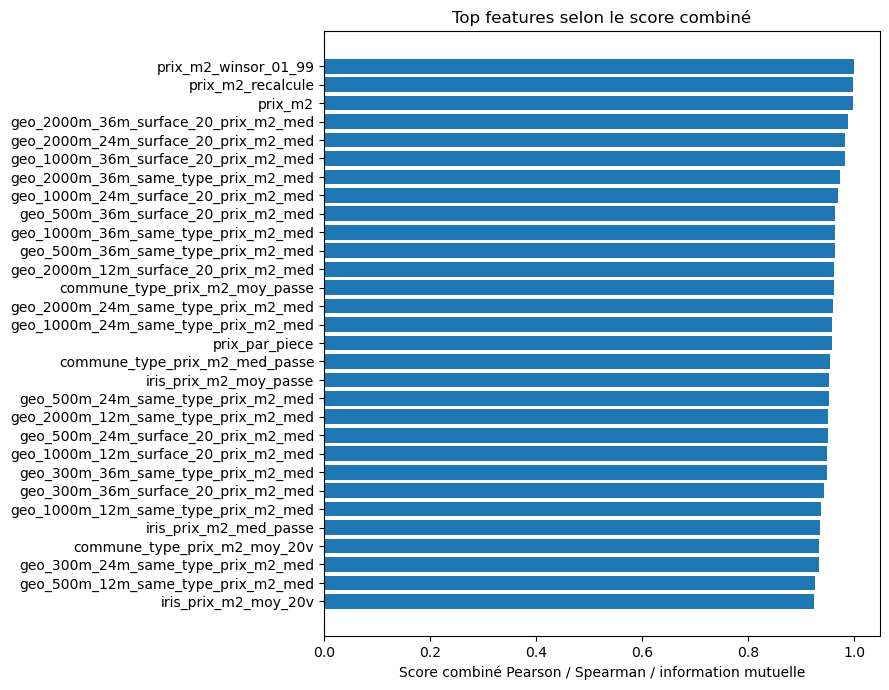

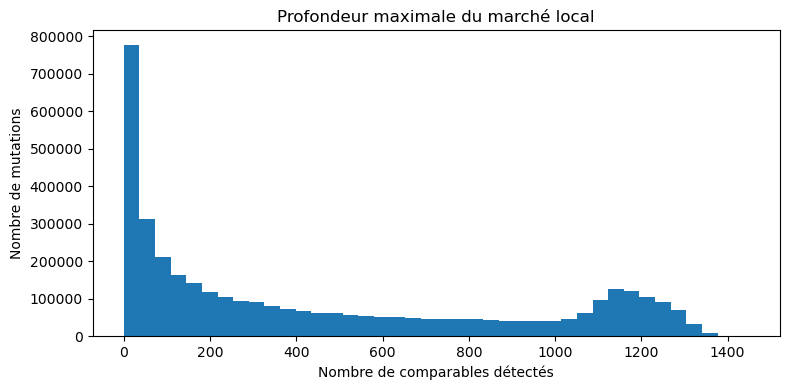

In [ ]:

# 13. Contrôles visuels


plot_scores = feature_selection.head(30).sort_values("score_selection")

plt.figure(figsize=(9, 7))
plt.barh(plot_scores["variable_selection"], plot_scores["score_selection"])
plt.title("Top features selon le score combiné")
plt.xlabel("Score combiné Pearson / Spearman / information mutuelle")
save_fig("top_features_score_selection.png")

if "geo_nb_comparables_max" in base_features_finale.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(base_features_finale["geo_nb_comparables_max"].dropna(), bins=40)
    plt.title("Profondeur maximale du marché local")
    plt.xlabel("Nombre de comparables détectés")
    plt.ylabel("Nombre de mutations")
save_fig("distribution_nb_comparables.png")


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Traçabilité import 00_06</h3>
  <div style="color: #4b5563; font-size: 14px;">Le fichier source chargé et les éventuels fichiers temporels 00_06 sont sauvegardés dans un audit afin de documenter précisément la continuité du pipeline.</div>
</div>

In [ ]:
 ====
# 14. Audit de traçabilité 00_06
 ====

audit_import_00_06 = pd.DataFrame([
    {
        "role": "base_transactionnelle_alignee_00_06",
        "path": str(source_file),
        "existe": source_file.exists(),
        "lignes": len(df_raw),
        "colonnes": df_raw.shape[1],
    },
    {
        "role": "features_temporelles_00_06",
        "path": str(temporal_features_file),
        "existe": temporal_features_file.exists(),
        "lignes": None if temporal_features_00_06 is None else len(temporal_features_00_06),
        "colonnes": None if temporal_features_00_06 is None else temporal_features_00_06.shape[1],
    },
    {
        "role": "marche_temporel_complet_00_06",
        "path": str(temporal_market_file),
        "existe": temporal_market_file.exists(),
        "lignes": None if temporal_market_00_06 is None else len(temporal_market_00_06),
        "colonnes": None if temporal_market_00_06 is None else temporal_market_00_06.shape[1],
    },
])

audit_import_00_06.to_csv(TABLE_DIR / "audit_import_00_06.csv", index=False)
display(audit_import_00_06)


,role,path,existe,lignes,colonnes
0,base_transactionnelle_alignee_00_06,c:\Users\club_\OneDrive\13_DOCUMENT\Projet Com...,True,3885803,147
1,features_temporelles_00_06,c:\Users\club_\OneDrive\13_DOCUMENT\Projet Com...,True,60,14
2,marche_temporel_complet_00_06,c:\Users\club_\OneDrive\13_DOCUMENT\Projet Com...,True,60,41


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">CONCLUSION</h3>
  <div style="color: #4b5563; font-size: 14px;">Le notebook produit une base de features comparables sur le périmètre France entière / DVF, enrichie par les dimensions bien, temps, marché local et voisinage géographique. Toulouse peut rester un contrôle ponctuel, mais ne pilote plus la construction des variables.</div>
</div>